# Task 2: Time Series Analysis

## 1. Import the libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

## 2. Loading of cleaned dataset

In [2]:
df = pd.read_csv("cleaned_stock_prices-copy1.csv", sep=",")

In [3]:
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


## 3. Converting the date column to datetime

In [4]:
df['date'] = pd.to_datetime(df['date'])

df.dtypes

symbol               str
date      datetime64[us]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object

## 4. Selecting one stock for the time-series analysis

In [5]:
aapl = df[df['symbol'] == 'AAPL'].copy()

aapl = aapl.sort_values('date')

aapl.head()

,symbol,date,open,high,low,close,volume
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
484,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
967,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
1450,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
1933,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


## 5. Setting the date as the index

In [6]:
aapl.set_index('date', inplace=True)

aapl.head()

,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-03,AAPL,78.9799,79.0999,77.2042,77.2828,98303870
2014-01-06,AAPL,76.7785,78.1142,76.2285,77.7042,103359151
2014-01-07,AAPL,77.7599,77.9942,76.8464,77.1481,79432766
2014-01-08,AAPL,76.9728,77.9371,76.9556,77.6371,64686685


## 6. Creating our first time-series chart

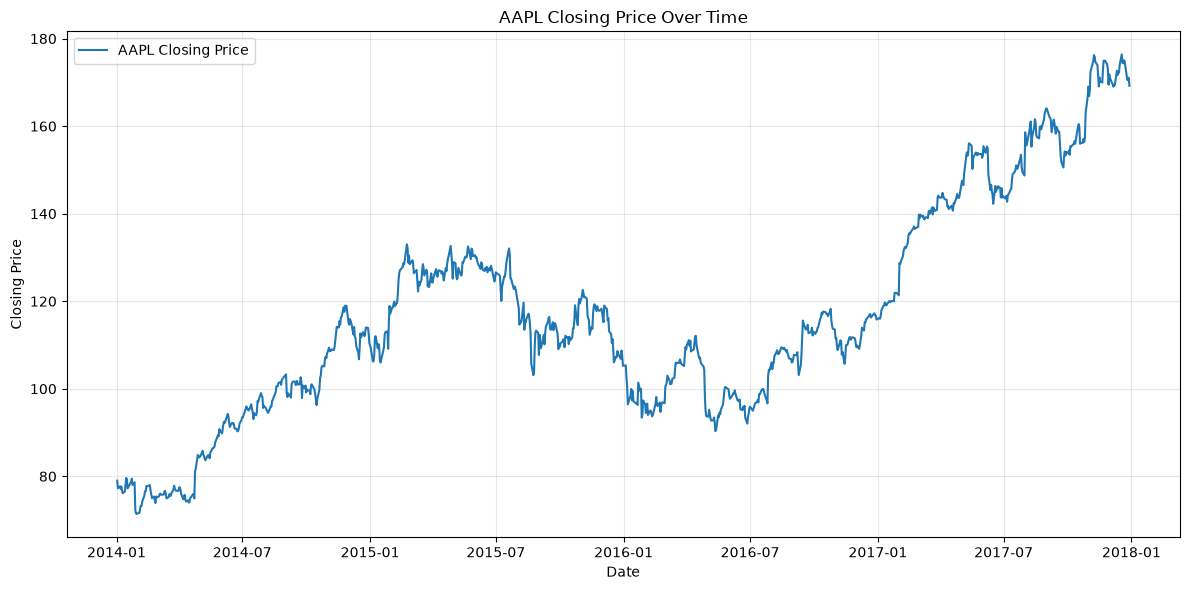

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    aapl.index,
    aapl['close'],
    linewidth=1.5,
    label='AAPL Closing Price'
)

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("AAPL Closing Price Over Time")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

## 7. Decomposing the time series

## Note: 
We'll have to break the AAPL closing-price series into:

1. Trend: the long-term movement
2. Seasonality: repeating patterns
3. Residual:  fluctuations not explained by the trend or seasonality

Before we decompose it, let's check how much AAPL data we have.

In [8]:
print("Number of observations:", len(aapl))
print("Start date:", aapl.index.min())
print("End date:", aapl.index.max())

Number of observations: 1007
Start date: 2014-01-02 00:00:00
End date: 2017-12-29 00:00:00


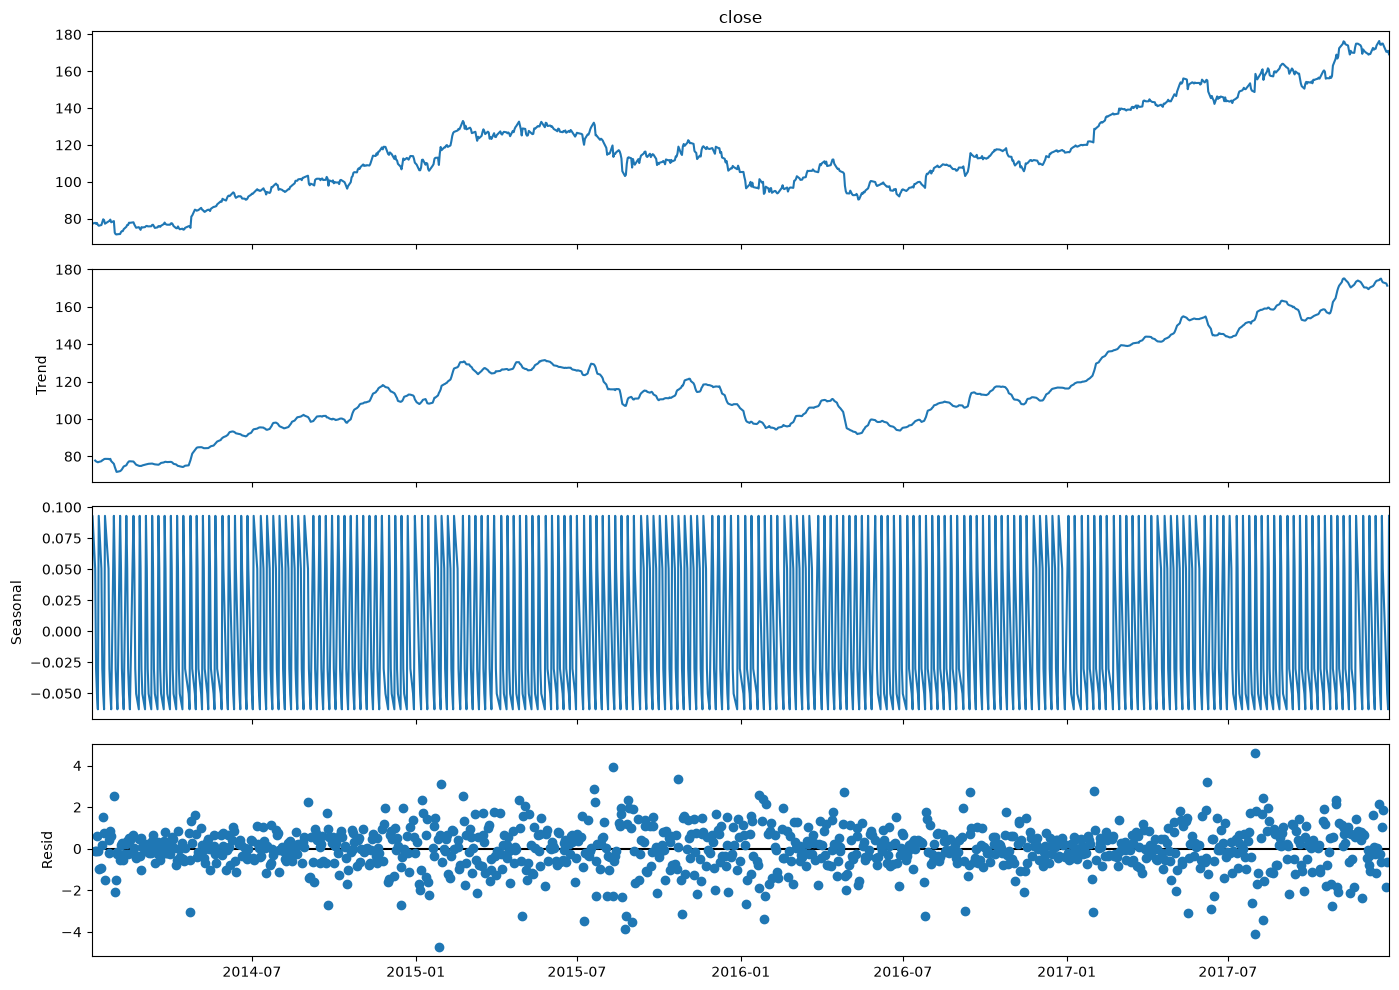

In [9]:
## Because these are daily stock-market observations, we'll use a seasonal period of 5 trading days, representing the typical Monday–Friday trading cycle.

decomposition = seasonal_decompose(
    aapl['close'],
    model='additive',
    period=5
)

fig = decomposition.plot()

fig.set_size_inches(14, 10)

plt.tight_layout()
plt.show()

## Interpretation
Time Series Decomposition: The AAPL closing-price series was decomposed into observed, trend, seasonal, and residual components using an additive model with a 5-trading-day seasonal period. The trend component revealed the underlying long-term movement of the stock, while the seasonal component showed relatively small repeating fluctuations. The residual component captured short-term and irregular movements not explained by the trend or seasonal pattern. Overall, the analysis suggests that AAPL's price movement during the period was driven more by its changing trend and irregular fluctuations than by a strong repeating weekly seasonal pattern.

## 8. Moving Average Smoothing

In [10]:
aapl['MA_20'] = aapl['close'].rolling(window=20).mean()

aapl[['close', 'MA_20']].head(25)

,close,MA_20
date,,
2014-01-02,79.0185,NaN
2014-01-03,77.2828,NaN
2014-01-06,77.7042,NaN
2014-01-07,77.1481,NaN
2014-01-08,77.6371,NaN
2014-01-09,76.6455,NaN
2014-01-10,76.1342,NaN
2014-01-13,76.5328,NaN
2014-01-14,78.0556,NaN


## 9.  Plotting the Moving Average

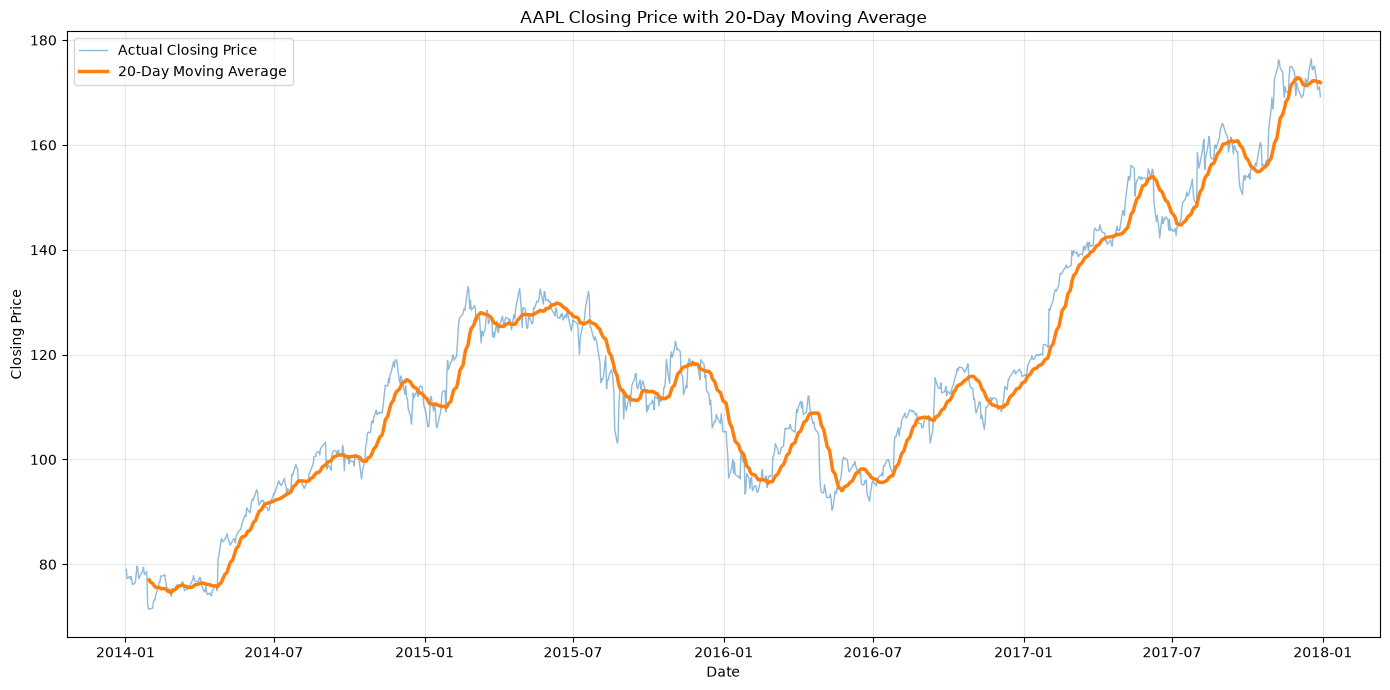

In [11]:
plt.figure(figsize=(14, 7))

plt.plot(
    aapl.index,
    aapl['close'],
    label='Actual Closing Price',
    alpha=0.5,
    linewidth=1
)

plt.plot(
    aapl.index,
    aapl['MA_20'],
    label='20-Day Moving Average',
    linewidth=2.5
)

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("AAPL Closing Price with 20-Day Moving Average")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

## 10. Interpreting the Moving Average

Moving Average Analysis: A 20-day moving average was applied to AAPL's closing prices to reduce short-term fluctuations and highlight the underlying trend. The moving-average line is smoother than the actual closing-price series, making periods of upward and downward movement easier to identify. This demonstrates how moving-average smoothing can be used to reduce daily market noise and provide a clearer view of the stock's overall price direction